In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import sys
sys.path.append("../src")

from quantvol.models.ml.lgbm_model import FEATURE_COLS, TARGET_COL

df = pd.read_csv("../data/processed/ml_features.csv", parse_dates=["Date"])
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)

df.shape

(2807, 23)

In [2]:
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    verbosity=0,
)

model.fit(df[FEATURE_COLS], df[TARGET_COL])
print("Model fitted")

Model fitted


In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df[FEATURE_COLS])

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2807, 11)


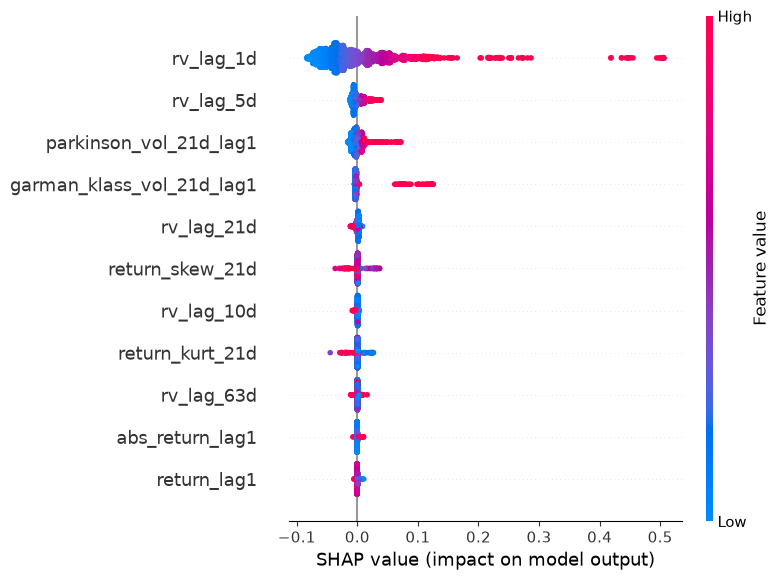

In [4]:
shap.summary_plot(shap_values, df[FEATURE_COLS], show=False)
plt.tight_layout()
plt.show()

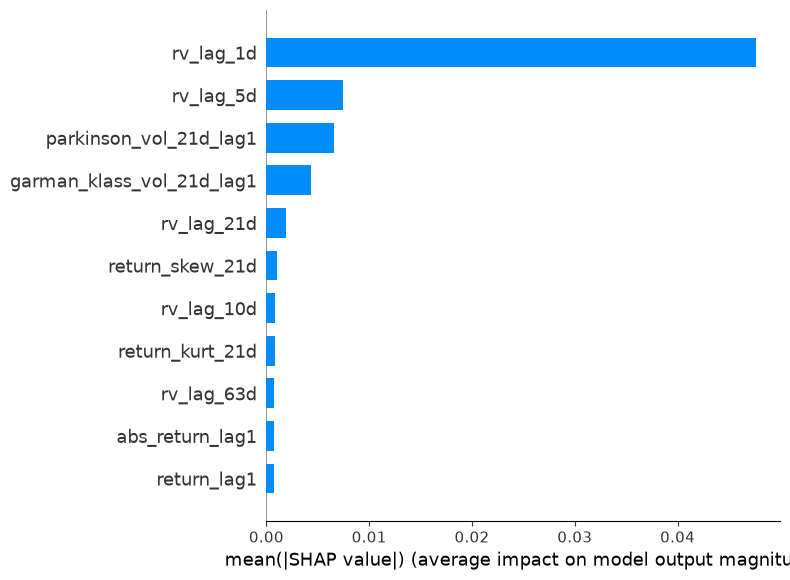

In [5]:
shap.summary_plot(shap_values, df[FEATURE_COLS], plot_type="bar", show=False)
plt.tight_layout()
plt.show()